# Machine Learning Pipeline: Adult Census Income

**Mục tiêu:** Xây dựng mô hình phân loại dự đoán thu nhập (Income >50K).

In [21]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)


## 1. Thu Thập Dữ Liệu

In [22]:
print('Đang tải dữ liệu từ Kaggle (Công khai, tự động không cần Mount Drive)...')
path = kagglehub.dataset_download('uciml/adult-census-income')
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

print('Kích thước:', df.shape)
display(df.head())


Đang tải dữ liệu từ Kaggle (Công khai, tự động không cần Mount Drive)...
Kích thước: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Khám Phá Dữ Liệu - Tổng quan EDA
(Trực quan hóa Boxplot, Heatmap Tương quan và Mối liên hệ Categorical)

In [23]:
# Xử lý giá trị lỗi nhanh để thống kê
df.replace('?', np.nan, inplace=True)
target_col = 'income' if 'income' in df.columns else df.columns[-1]

print("="*60)
print("THÔNG TIN TỔNG QUAN")
print("="*60)
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


THÔNG TIN TỔNG QUAN
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
None

Missing Values:
workclass         1836
occupation        1843
native.country     583
dtype: int64


### 2.1 Trực quan hóa Biến Số (Numerical) & Tương Quan

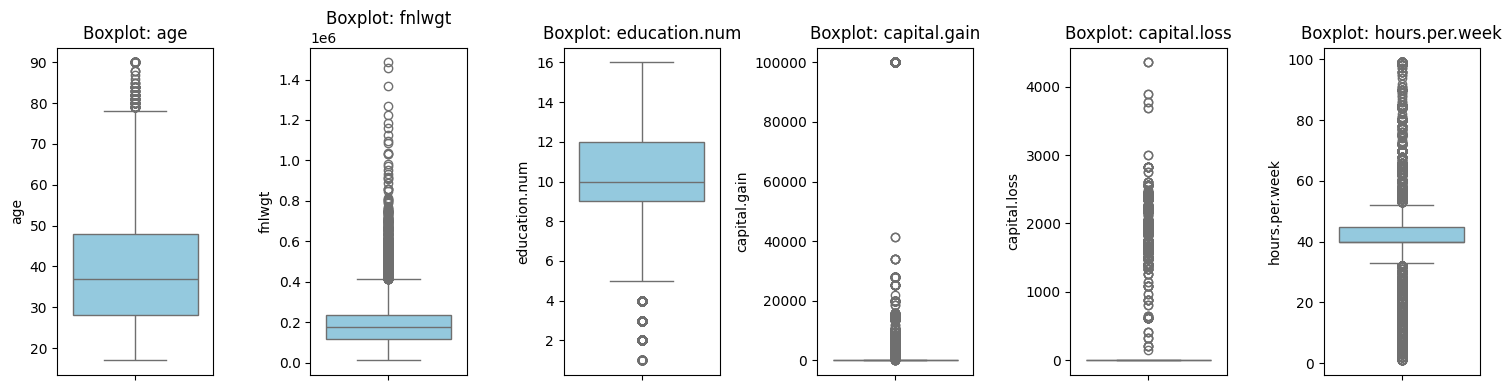

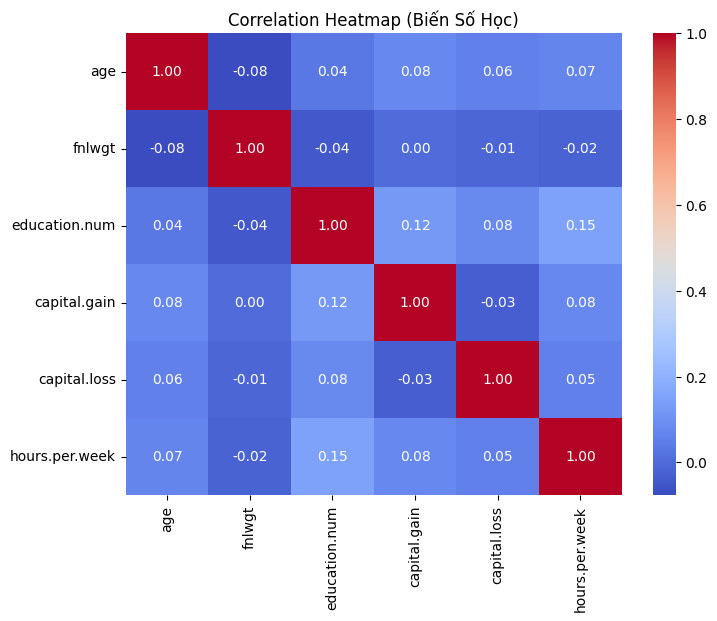

In [24]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 1. Boxplot (Ngoại lai - Outliers)
plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

# 2. Ma trận tương quan (Correlation Heatmap)
plt.figure(figsize=(8, 6))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Biến Số Học)")
plt.show()


### 2.2 Trực quan hóa Biến Phân Loại (Categorical) VS Target

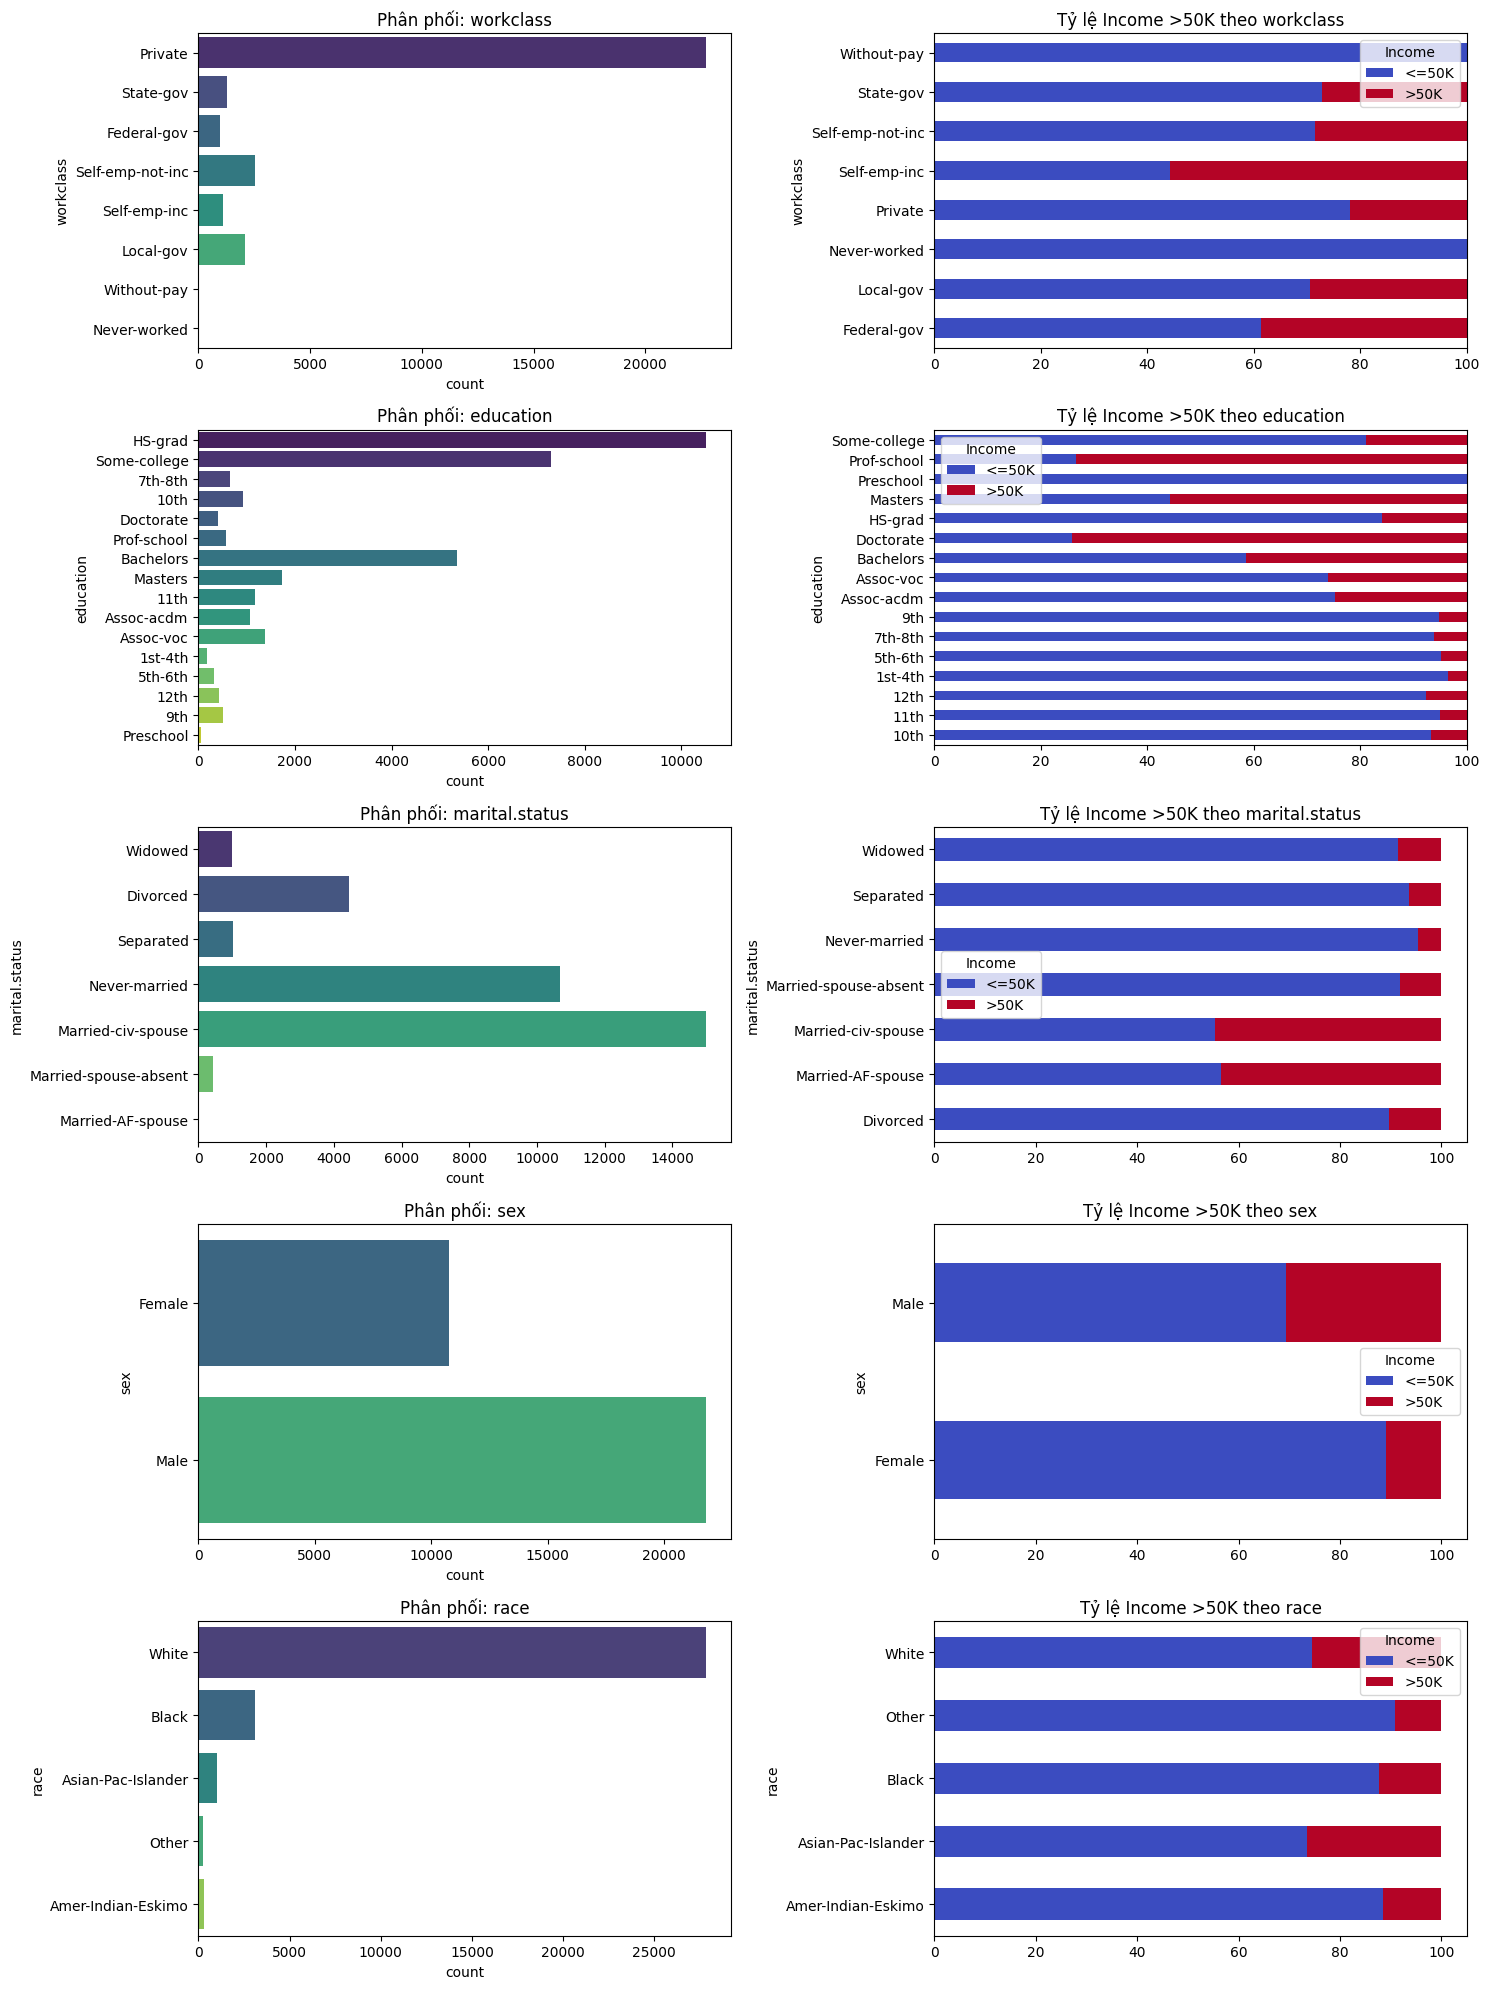

In [25]:
# Chọn ra các cột categorical nổi bật nhất đê vẽ (giới hạn 5 cột dễ nhìn nhất)
top_cats = ['workclass', 'education', 'marital.status', 'sex', 'race']
if not all(c in df.columns for c in top_cats):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if target_col in cat_cols: cat_cols.remove(target_col)
    top_cats = cat_cols[:5]

fig, axes = plt.subplots(len(top_cats), 2, figsize=(15, 4 * len(top_cats)))

for i, col in enumerate(top_cats):
    # Đồ thị 1: Số lượng
    sns.countplot(y=col, data=df, ax=axes[i, 0], palette='viridis')
    axes[i, 0].set_title(f"Phân phối: {col}")
    
    # Đồ thị 2: Stacked Bar xem Tỷ lệ Income
    ct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
    ct.plot(kind='barh', stacked=True, ax=axes[i, 1], colormap='coolwarm')
    axes[i, 1].set_title(f"Tỷ lệ Income >50K theo {col}")
    axes[i, 1].legend(title='Income')

plt.tight_layout()
plt.show()


## 3. Tiền Xử Lý (Preprocessing Pipeline)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

df[target_col] = df[target_col].astype(str).str.replace('.', '', regex=False).str.strip()
df[target_col] = (df[target_col] == '>50K').astype(int)

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

# Xử lý dữ liệu số học với SimpleImputer + StandardScaler
num_transformer = ImbPipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
# Xử lý dữ liệu danh mục với SimpleImputer + OneHotEncoder
cat_transformer = ImbPipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Missing_Value')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_cols), ('cat', cat_transformer, cat_cols)])
print("Hoàn tất cấu hình Tiền xử lý (Preprocessing)!")


Hoàn tất cấu hình Tiền xử lý (Preprocessing)!


## 4. Huấn Luận Mô Hình & So Sánh (Logistic Regression vs Random Forest vs LightGBM)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix, roc_curve

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=150, learning_rate=0.1, max_depth=8, class_weight='balanced', random_state=42)
}

results = []
trained_pipelines = {}

import time
for name, model in models.items():
    print(f'Đang huấn luyện {name} (Có SMOTE=0.5)...')
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
        ('classifier', model)
    ])
    
    start_time = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else pipe.decision_function(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    results.append({'Mô hình': name, 'Accuracy': acc, 'ROC AUC': roc, 'Thời gian (s)': train_time})
    trained_pipelines[name] = pipe

# IN BẢNG SO SÁNH TRUYỀN THỐNG
print('\n--- BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRUYỀN THỐNG ---')
results_df = pd.DataFrame(results).sort_values(by='ROC AUC', ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]['Mô hình']
print(f"\nMô hình truyền thống xuất sắc nhất là {best_model_name}!")
best_pipe = trained_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)
y_prob_best = best_pipe.predict_proba(X_test)[:, 1]


Đang huấn luyện Logistic Regression (Có SMOTE=0.5)...
Đang huấn luyện Random Forest (Có SMOTE=0.5)...
Đang huấn luyện LightGBM (Có SMOTE=0.5)...
[LightGBM] [Info] Number of positive: 9887, number of negative: 19775
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3356
[LightGBM] [Info] Number of data points in the train set: 29662, number of used features: 97
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

--- BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRUYỀN THỐNG ---


,Mô hình,Accuracy,ROC AUC,Thời gian (s)
0,LightGBM,0.842315,0.921241,0.443577
1,Logistic Regression,0.808383,0.904008,0.519608
2,Random Forest,0.787502,0.901586,1.732723



Mô hình truyền thống xuất sắc nhất là LightGBM!


## 5. Mạng Nơ-ron Deep Learning (MLP Pytorch)

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_train_dl = best_pipe.named_steps['preprocessor'].transform(X_train)
X_test_dl = best_pipe.named_steps['preprocessor'].transform(X_test)

smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_dl_res, y_train_res = smote.fit_resample(X_train_dl, y_train)

class CategoricalMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 2)
        )
    def forward(self, x): return self.net(x)
        
model_dl = CategoricalMLP(X_train_dl_res.shape[1])
# Class weight phạt mạnh rủi ro thiểu số
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.0]))
optimizer = torch.optim.Adam(model_dl.parameters(), lr=0.001)

dataset = TensorDataset(torch.FloatTensor(X_train_dl_res), torch.LongTensor(y_train_res.values))
loader = DataLoader(dataset, batch_size=128, shuffle=True)

print('Đang huấn luyện MLP PyTorch...')
model_dl.train()
for epoch in range(12):
    for inputs, targets in loader:
        optimizer.zero_grad()
        loss = criterion(model_dl(inputs), targets)
        loss.backward()
        optimizer.step()
print('Hoàn tất huấn luyện Deep Learning!')

model_dl.eval()
with torch.no_grad():
    outputs = model_dl(torch.FloatTensor(X_test_dl))
    y_prob_dl = torch.softmax(outputs, dim=1)[:, 1].numpy()
    y_pred_dl = torch.argmax(outputs, dim=1).numpy()
dl_acc = accuracy_score(y_test, y_pred_dl)
dl_roc = roc_auc_score(y_test, y_prob_dl)


Đang huấn luyện MLP PyTorch...
Hoàn tất huấn luyện Deep Learning!


## 6. Đánh Giá Biểu Đồ Tổng Quan: Traditional ML vs Deep Learning

,Thuật Toán,Accuracy,ROC AUC,F1-Score
0,LightGBM (Truyền thống),0.842315,0.921241,0.801546
1,MLP (Deep Learning),0.801781,0.906212,0.765762


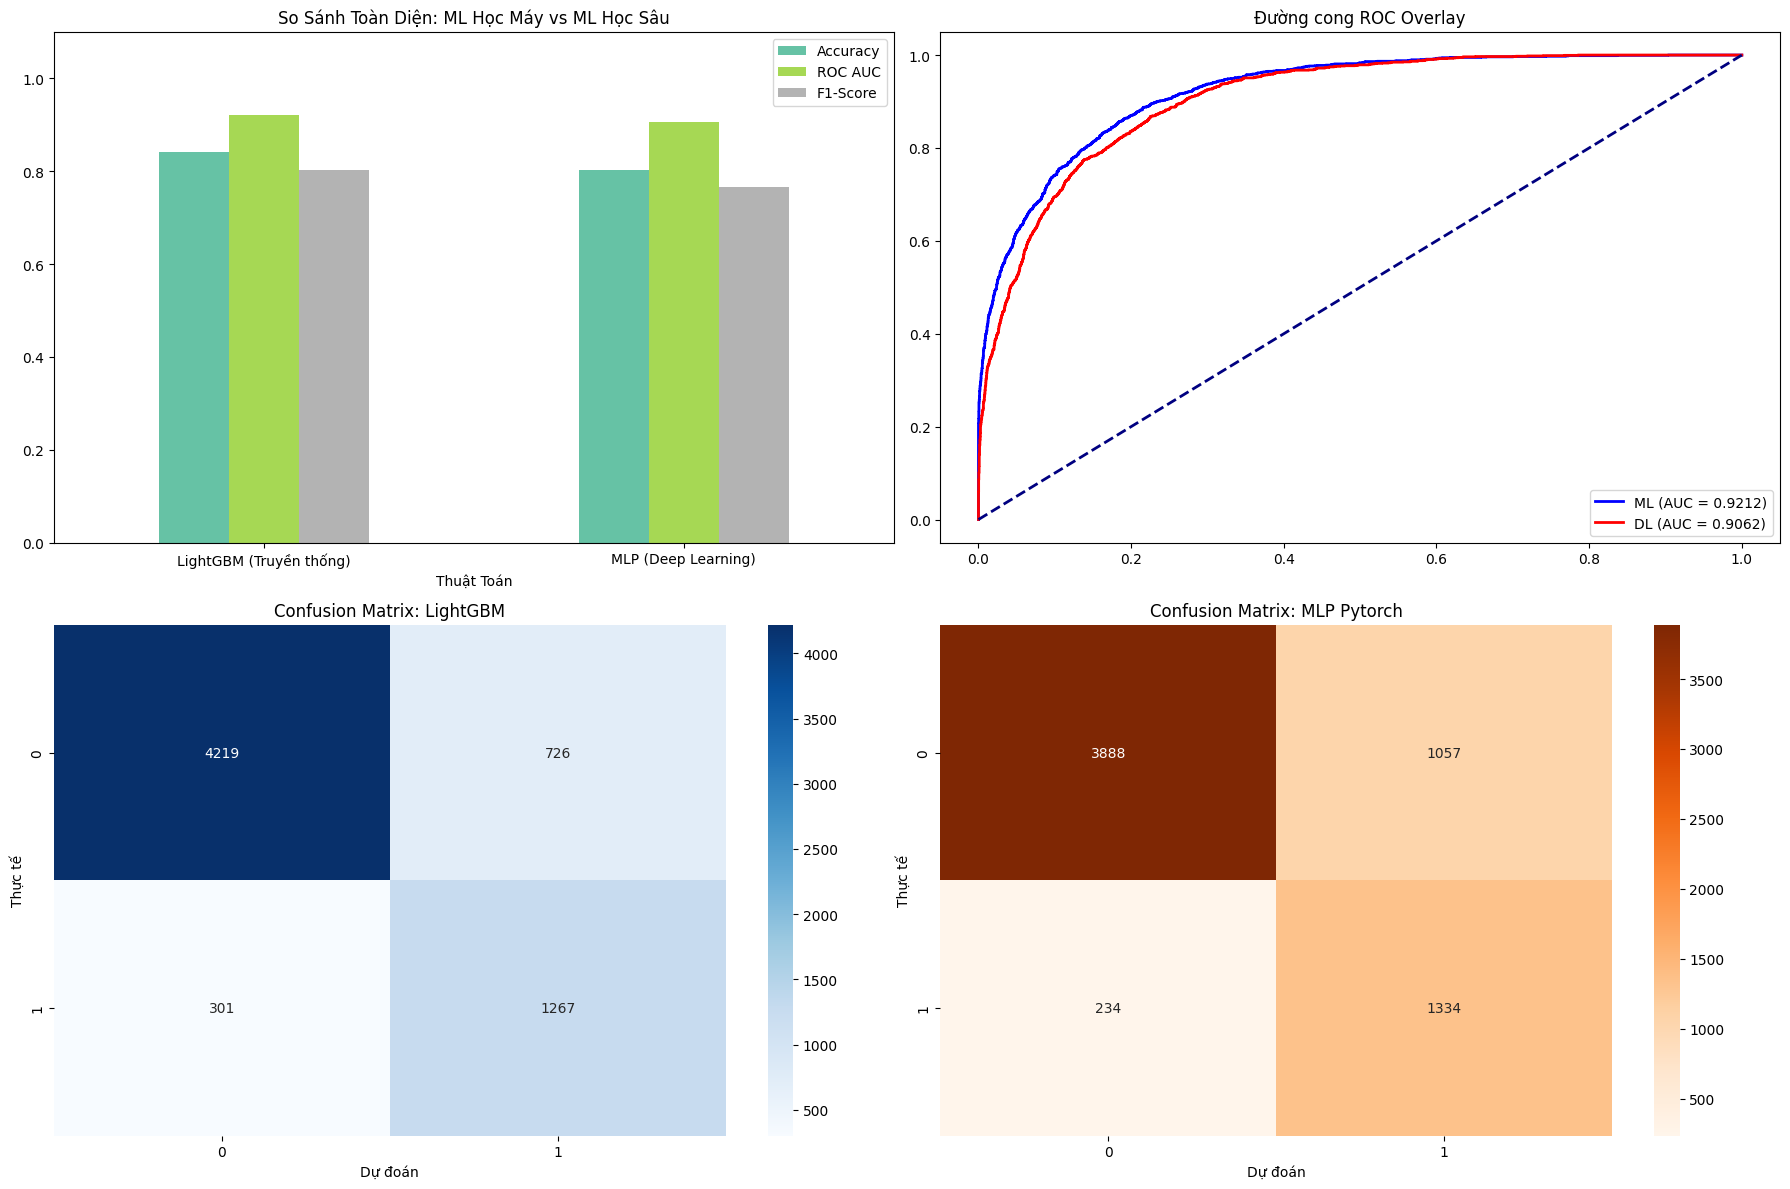

In [29]:
compare_data = {
    'Thuật Toán': [f'{best_model_name} (Truyền thống)', 'MLP (Deep Learning)'],
    'Accuracy': [accuracy_score(y_test, y_pred_best), dl_acc],
    'ROC AUC': [roc_auc_score(y_test, y_prob_best), dl_roc],
    'F1-Score': [classification_report(y_test, y_pred_best, output_dict=True)['macro avg']['f1-score'], classification_report(y_test, y_pred_dl, output_dict=True)['macro avg']['f1-score']],
}
display(pd.DataFrame(compare_data))

# VẼ BIỂU ĐỒ BARCHART SO SÁNH & CONFUSION MATRIX & ROC CURVE (ĐỦ ALL CHARTS)
fig = plt.figure(figsize=(18, 12))

# 1. Bar Chart
ax1 = plt.subplot(2, 2, 1)
df_bar = pd.DataFrame(compare_data).set_index('Thuật Toán')
df_bar.plot(kind='bar', ax=ax1, colormap='Set2')
ax1.set_title('So Sánh Toàn Diện: ML Học Máy vs ML Học Sâu')
ax1.set_ylim([0, 1.1])
plt.xticks(rotation=0)

# 2. ROC Curve
ax2 = plt.subplot(2, 2, 2)
fpr_ml, tpr_ml, _ = roc_curve(y_test, y_prob_best)
ax2.plot(fpr_ml, tpr_ml, color='blue', lw=2, label=f'ML (AUC = {roc_auc_score(y_test, y_prob_best):.4f})')
fpr_dl, tpr_dl, _ = roc_curve(y_test, y_prob_dl)
ax2.plot(fpr_dl, tpr_dl, color='red', lw=2, label=f'DL (AUC = {dl_roc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_title('Đường cong ROC Overlay')
ax2.legend(loc='lower right')

# 3. Confusion Matrix ML
ax3 = plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_title(f'Confusion Matrix: {best_model_name}')
ax3.set_ylabel('Thực tế')
ax3.set_xlabel('Dự đoán')

# 4. Confusion Matrix DL
ax4 = plt.subplot(2, 2, 4)
sns.heatmap(confusion_matrix(y_test, y_pred_dl), annot=True, fmt='d', cmap='Oranges', ax=ax4)
ax4.set_title('Confusion Matrix: MLP Pytorch')
ax4.set_ylabel('Thực tế')
ax4.set_xlabel('Dự đoán')

plt.tight_layout()
plt.show()


### 7. LƯU ĐẶC TRƯNG VÀ MÔ HÌNH NỘP BÀI

In [30]:
import joblib

import os\n# Nếu chạy trên Local (trong thư mục notebooks) thì lùi ra Folder chính, Nếu trên Colab thì tạo ngay tại ổ đĩa hiện tại\nfeatures_dir = '../features' if os.path.basename(os.getcwd()) == 'notebooks' else 'features'
os.makedirs(features_dir, exist_ok=True)

np.save(os.path.join(features_dir, 'X_train_processed.npy'), X_train_dl_res)
np.save(os.path.join(features_dir, 'y_train_resampled.npy'), y_train_res)
np.save(os.path.join(features_dir, 'X_test_processed.npy'), X_test_dl)
np.save(os.path.join(features_dir, 'y_test.npy'), y_test.values)

joblib.dump(best_pipe, os.path.join(features_dir, 'best_classic_pipeline.pkl'))
torch.save(model_dl.state_dict(), os.path.join(features_dir, 'mlp_weights.pth'))

print("\nĐã lưu mảng Numpy Arrays và Pickle Models vào /features/ thành công!")



Đã lưu mảng Numpy Arrays và Pickle Models vào /features/ thành công!
